# 第 12 章 OpenCV 輪廓分析

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

### 12-1-3 程式範例：輪廓擷取與視覺化

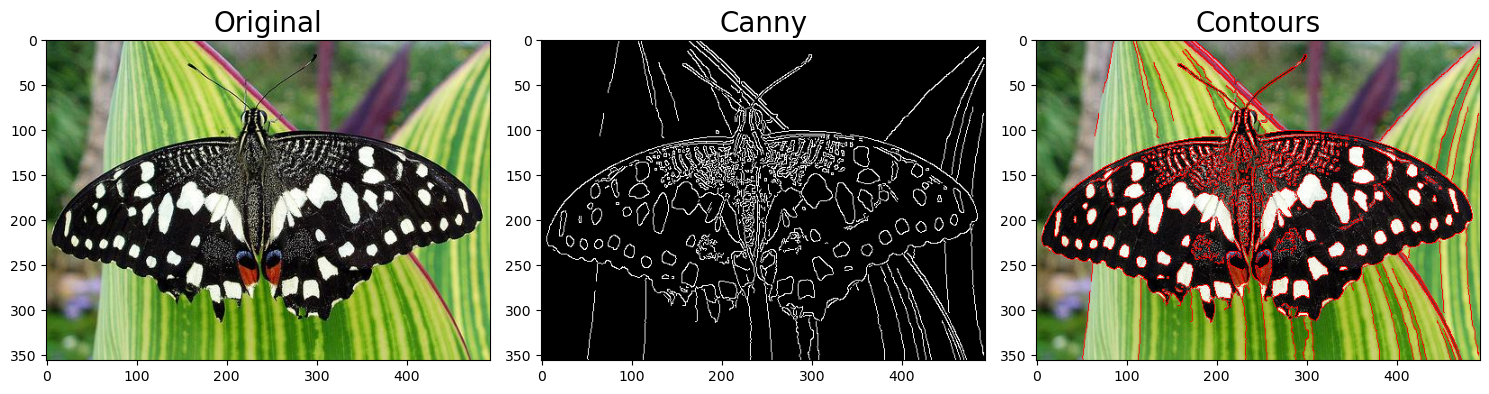

In [2]:
# 讀取原始影像並轉為灰階
img = cv2.imread('sample/butterfly.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 高斯模糊去雜訊
blur = cv2.GaussianBlur(gray, (3, 3), 0)

# 執行 Canny 邊緣偵測
canny = cv2.Canny(blur, 100, 200)

# 尋找輪廓
contours, hierarchy = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 將輪廓畫在原圖上
img_contour = img.copy()
cv2.drawContours(img_contour, contours, -1, (0, 0, 255), 1)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original', img,
    'Canny', canny,
    'Contours', img_contour,   
)

### 12-2-2 程式範例：計算最大輪廓面積

矩形輪廓的面積為： 10000.0


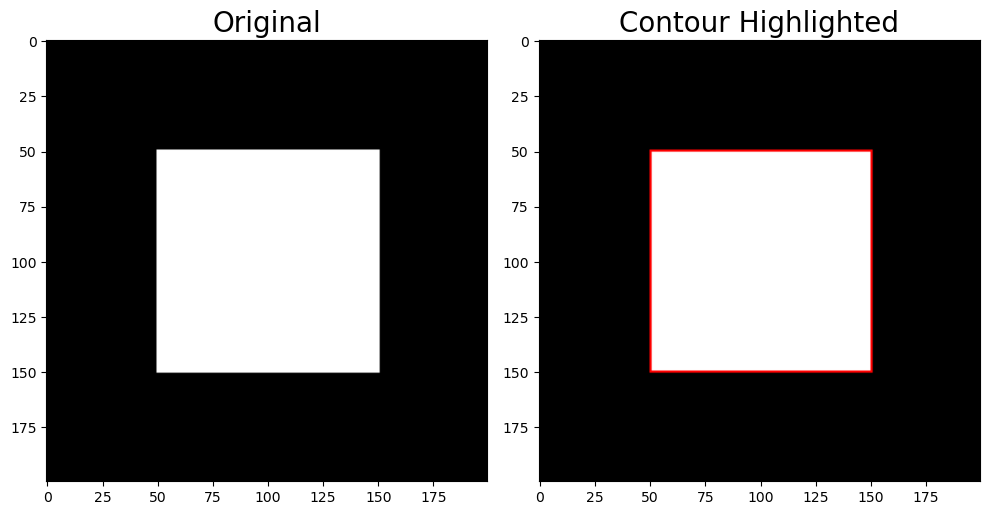

In [3]:
# 建立一個 200x200 的黑色底圖
img = np.zeros((200, 200), dtype=np.uint8)

# 在影像上繪製一個白色矩形（左上角 (50, 50)，右下角 (150, 150)）
# 面積理論值：100 × 100 = 10000
cv2.rectangle(img, (50, 50), (150, 150), 255, -1)

# 尋找最外層輪廓，只保留轉折點
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 從所有輪廓中挑出面積最大的輪廓
max_contour = max(contours, key=cv2.contourArea)

# 計算該輪廓所圍繞的面積
max_area = cv2.contourArea(max_contour)
print("矩形輪廓的面積為：", max_area)

# 先把灰階圖轉為 BGR 彩色圖，才能畫上紅色線
img_draw = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# 畫出最大的輪廓（thickness=1，細紅線）
cv2.drawContours(img_draw, [max_contour], -1, (0, 0, 255), 1)

# 並排顯示原圖與輪廓標示結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Original', img,
    'Contour Highlighted', img_draw,
)

### 12-3-2 程式範例：簡單圖形的外接矩形

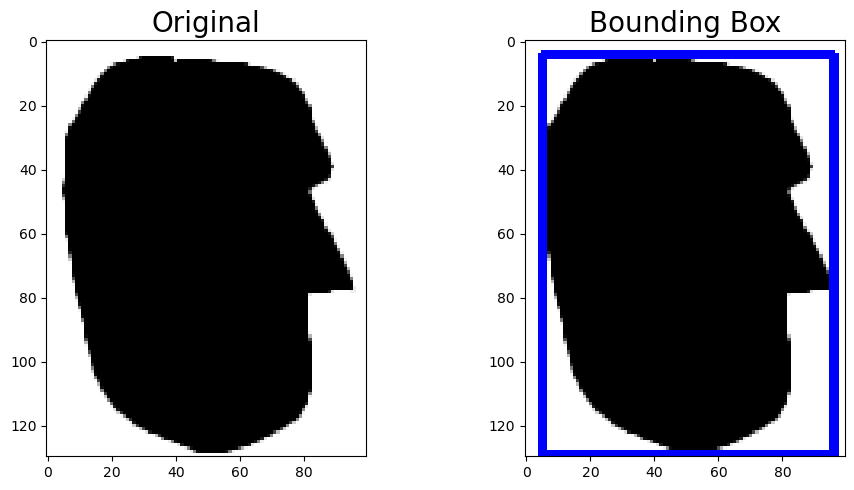

In [4]:
# 讀取原始影像並轉為灰階
img = cv2.imread('sample/templ.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 高斯模糊去雜訊
blur = cv2.GaussianBlur(gray, (3, 3), 0)

# 執行 Canny 邊緣偵測
edges = cv2.Canny(blur, 100, 200)

# 尋找輪廓
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 選出所有輪廓中面積最大的輪廓
max_contour = max(contours, key=cv2.contourArea)

# 取得最大輪廓的外接矩形座標
x, y, w, h = cv2.boundingRect(max_contour)

# 複製原圖以便繪製 bbox
img_bbox = img.copy()

# 繪製最大輪廓
cv2.rectangle(img_bbox, (x, y), (x + w, y + h), (255, 0, 0), 2)  # 藍色框線

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Original', img,
    'Bounding Box', img_bbox
)

### 12-3-3 程式範例：透過「形態學」處理實務上的複雜圖形

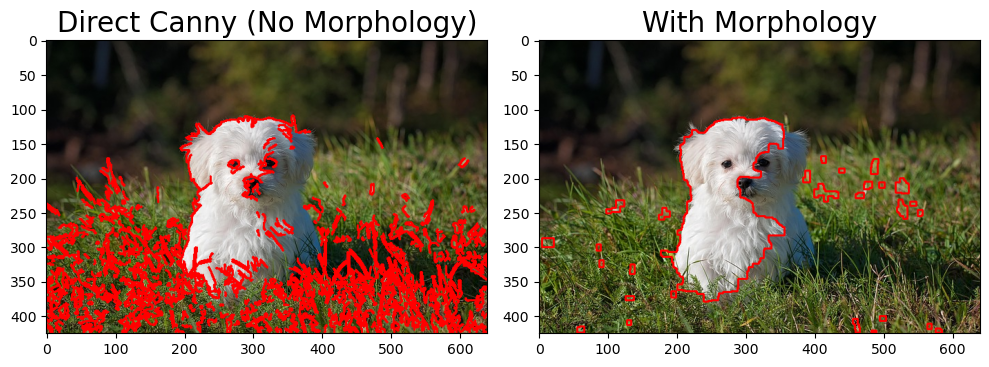

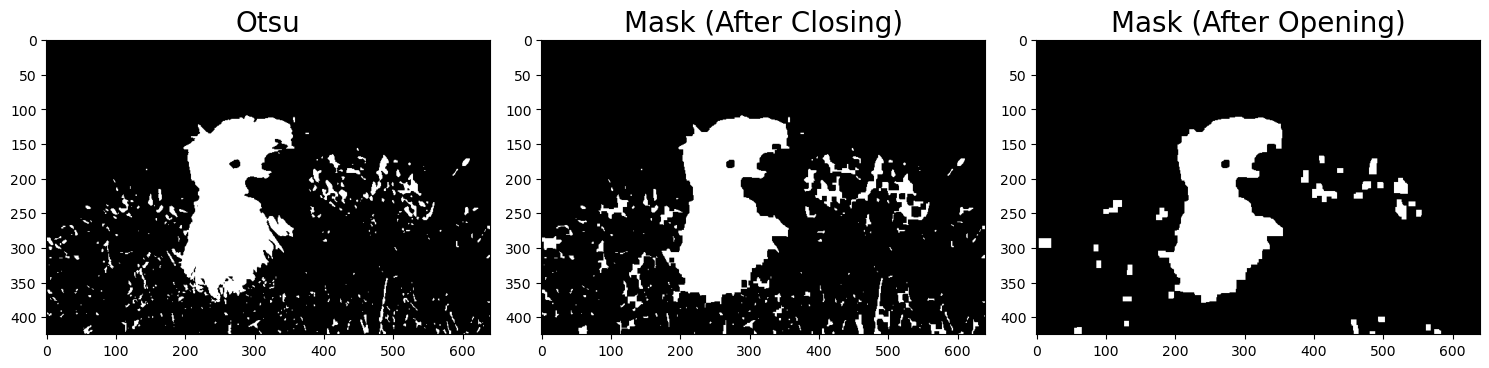

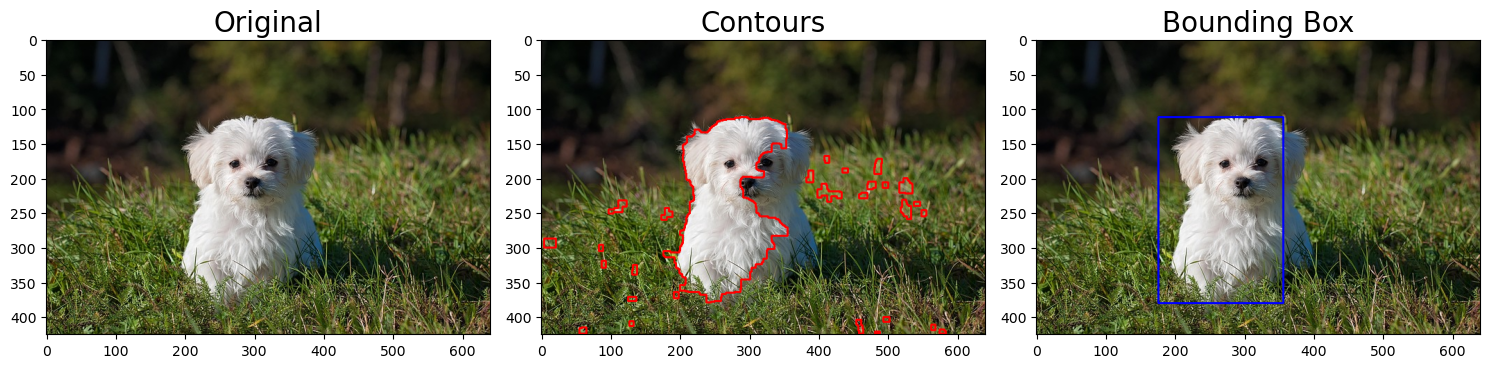

In [5]:
IMAGE_PATH = 'sample/dog.jpg'  # 圖片路徑

# 讀取原始影像並轉為灰階
img = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# 高斯模糊去雜訊
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# ===== 對照組：直接 Canny 邊緣偵測（未經形態學處理） =====
canny_direct = cv2.Canny(blur, 100, 200)
contours_direct, _ = cv2.findContours(canny_direct, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contour_direct = img.copy()
cv2.drawContours(img_contour_direct, contours_direct, -1, (0, 0, 255), 2)

# ===== 實驗組：Otsu + 形態學處理 =====
# Otsu 二值化：把白色的狗狗主體從背景中分離出來
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 形態學運算：建立 7×7 矩形結構元素
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
# 閉運算：把主體內部的小洞補起來
closed_mask = cv2.morphologyEx(otsu, cv2.MORPH_CLOSE, kernel)
# 開運算：把背景非主體的部分進行消除
opened_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, kernel)

# 尋找輪廓
contours, _ = cv2.findContours(opened_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 將輪廓畫在原圖上
img_contour = img.copy()
cv2.drawContours(img_contour, contours, -1, (0, 0, 255), 2)

# 選出面積最大的輪廓並繪製外接矩形
max_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(max_contour)
img_bbox = img.copy()
cv2.rectangle(img_bbox, (x, y), (x + w, y + h), (255, 0, 0), 2)  # 藍色框線

# ===== 顯示結果 =====

# 對照組 vs 實驗組的輪廓偵測結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Direct Canny (No Morphology)', img_contour_direct,
    'With Morphology', img_contour,
)

# 形態學處理過程
opencv_tools.show_img_by_matplotlib_1x3(
    'Otsu', otsu,
    'Mask (After Closing)', closed_mask,
    'Mask (After Opening)', opened_mask,
)

# 最終結果比較
opencv_tools.show_img_by_matplotlib_1x3(
    'Original', img,
    'Contours', img_contour,
    'Bounding Box', img_bbox,
)

### 12-E-1 範例結果：蝴蝶圖片的外接矩形

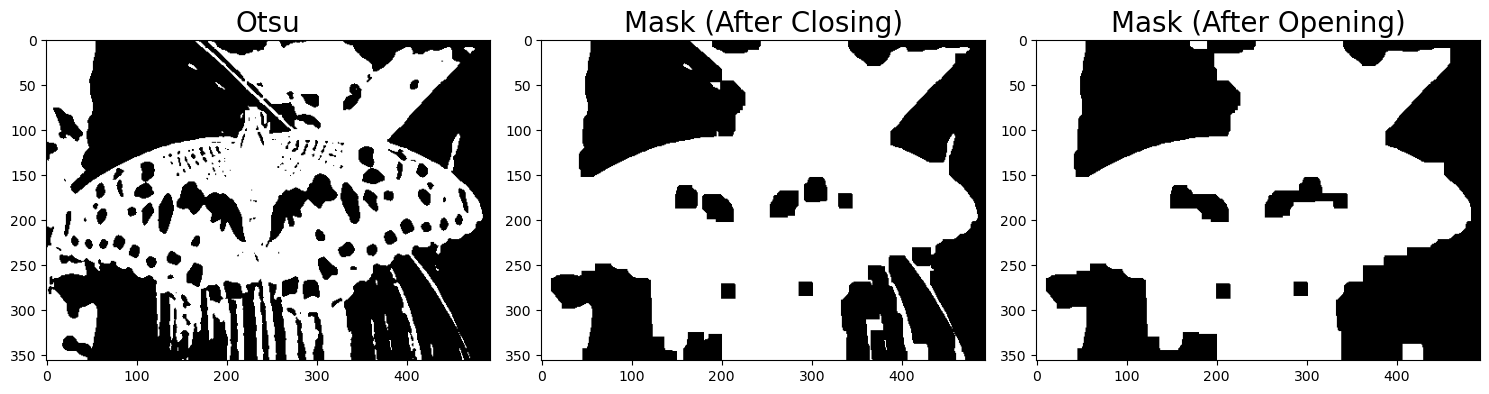

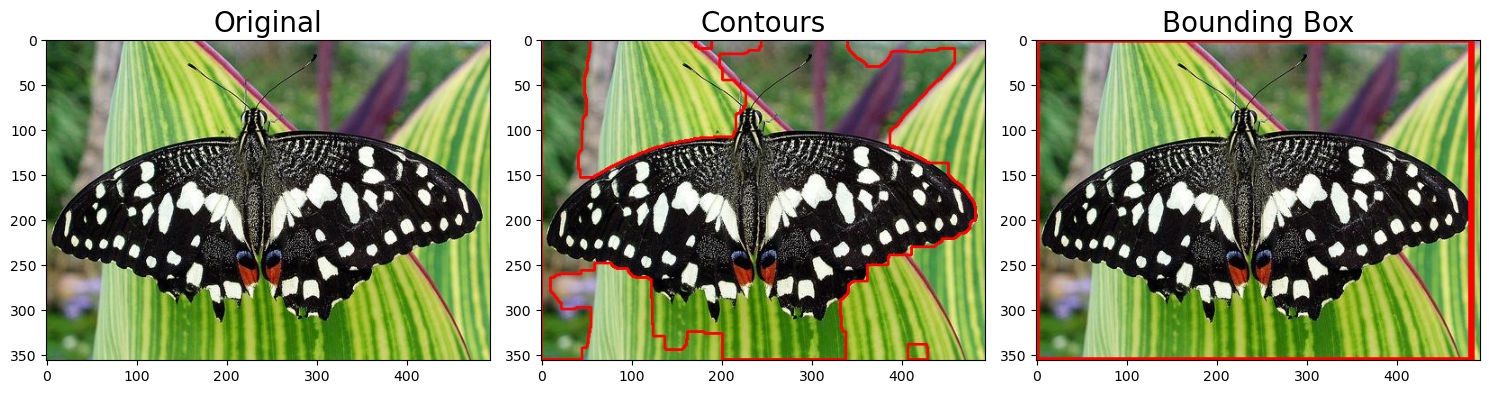

In [6]:
IMAGE_PATH = 'sample/butterfly.jpg'  # 圖片路徑

# 讀取原始影像並轉為灰階
img = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# 高斯模糊去雜訊
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# ===== Otsu + 形態學處理 =====
# 修改 1：因蝴蝶為「暗色主體 + 亮色葉子背景」，改用 INV 反向二值化
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 修改 2：蝴蝶翅膀上有許多白色斑點，使用較大的 kernel 才能填補
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
# 閉運算：填補主體內部的破洞（特別是翅膀上的白色斑點）
closed_mask = cv2.morphologyEx(otsu, cv2.MORPH_CLOSE, kernel)
# 開運算：消除背景中的非主體雜訊
opened_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, kernel)

# ===== 輪廓偵測與外接矩形 =====
# 尋找輪廓
contours, _ = cv2.findContours(opened_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 將所有輪廓畫在原圖上
img_contour = img.copy()
cv2.drawContours(img_contour, contours, -1, (0, 0, 255), 2)

# 選出面積最大的輪廓並繪製外接矩形
max_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(max_contour)
img_bbox = img.copy()
cv2.rectangle(img_bbox, (x, y), (x + w, y + h), (0, 0, 255), 6)  # 紅色粗框線

# ===== 顯示結果 =====

# 形態學處理過程
opencv_tools.show_img_by_matplotlib_1x3(
    'Otsu', otsu,
    'Mask (After Closing)', closed_mask,
    'Mask (After Opening)', opened_mask,
)

# 最終結果比較
opencv_tools.show_img_by_matplotlib_1x3(
    'Original', img,
    'Contours', img_contour,
    'Bounding Box', img_bbox,
)